In [1]:
import pandas as pd
import requests
import os

df = pd.read_csv('cs552j_A1_dataset_image_id_url.csv')

In [2]:
# Folder where you want to save the image
save_folder = "a1_images"
os.makedirs(save_folder, exist_ok=True)

In [3]:
def download_image(image_url, save_folder):
    image_name = os.path.join(save_folder, image_url.split("/")[-1])
    response = requests.get(image_url)
    if response.status_code == 200:
        with open(image_name, "wb") as file:
            file.write(response.content)
        print(f"Image saved at: {image_name}")
    else:
        print("Failed to download image")

In [4]:
# # downloads all the images to your computer. Do this only once locally, then you can continue.

for i in df.coco_url.values:
    download_image(i, save_folder)

Image saved at: a1_images/000000252219.jpg
Image saved at: a1_images/000000386912.jpg
Image saved at: a1_images/000000308394.jpg
Image saved at: a1_images/000000456496.jpg
Image saved at: a1_images/000000185250.jpg
Image saved at: a1_images/000000356427.jpg
Image saved at: a1_images/000000266409.jpg
Image saved at: a1_images/000000515579.jpg
Image saved at: a1_images/000000551215.jpg
Image saved at: a1_images/000000057597.jpg
Image saved at: a1_images/000000399462.jpg
Image saved at: a1_images/000000494869.jpg
Image saved at: a1_images/000000329219.jpg
Image saved at: a1_images/000000214720.jpg
Image saved at: a1_images/000000459153.jpg
Image saved at: a1_images/000000295713.jpg
Image saved at: a1_images/000000273132.jpg
Image saved at: a1_images/000000476415.jpg
Image saved at: a1_images/000000292082.jpg
Image saved at: a1_images/000000122046.jpg
Image saved at: a1_images/000000352684.jpg
Image saved at: a1_images/000000512836.jpg
Image saved at: a1_images/000000177015.jpg
Image saved

# Your Assessment code below

- please make good use of markdown to separate the sections.

# CS552J Assessment 1: Human Activity Classification from Still Images

**Authors:** Faizan Abbas & Zhanel Gharifullina

---

This notebook documents our full experimental pipeline for classifying human activities (sitting, standing, walking/running) from a subset of MS COCO images. It covers exploratory data analysis, two modelling approaches (supervised and self-supervised), training details, evaluation results, and a comparative analysis of both methods.

## 1. Exploratory Data Analysis

This section examines the dataset before any modelling is done. Understanding class balance, image properties, and potential preprocessing needs can help inform decisions made in the modelling stages.

### 1.1 Dataset overview and class distribution

The dataset consists of still images taken from MS COCO (Microsoft Common Objects in Context), a large-scale computer vision benchmark that contains images paired with object annotations and human keypoints (Lin et. al, 2014). From this resource, a curated subset was provided that focuses on three human activity classes: **sitting**, **standing**, and **walking/running**.

The images were provided as a CSV file (`cs552j_A1_dataset_image_id_url.csv`) containing each image's COCO ID, URL, filename, and activity label. Images were downloaded from the COCO CDN using the provided URLs and stored locally in the `a1_images/` folder.

The table below shows the class distribution across all samples. The dataset is moderately imbalanced, with sitting and standing images more common than walking/running. The imbalance ratio (max class count / min class count) is printed alongside the chart. This matters because a naive classifier that always predicts the majority class could appear to perform reasonably well under pure accuracy, which is why we also track macro-averaged F1 throughout.

The dataset contains 285 images distributed across three activity classes as shown below.

| Class | Count | Share |
|---|---|---|
| sitting | 95 | 33.3% |
| standing | 92 | 32.3% |
| walking_running | 98 | 34.4% |
| **Total** | **285** | **100%** |

However, the maximum difference between the most and least frequent class is of 6 samples, which is not large enough to justify resampling. This also led us to using stratification when splitting the training and test sets to preserve this distribution across all subsets

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 285 entries, 0 to 284
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Unnamed: 0     285 non-null    int64 
 1   license        285 non-null    int64 
 2   file_name      285 non-null    object
 3   coco_url       285 non-null    object
 4   height         285 non-null    int64 
 5   width          285 non-null    int64 
 6   date_captured  285 non-null    object
 7   flickr_url     285 non-null    object
 8   id             285 non-null    int64 
 9   label          285 non-null    object
dtypes: int64(5), object(5)
memory usage: 22.4+ KB
None


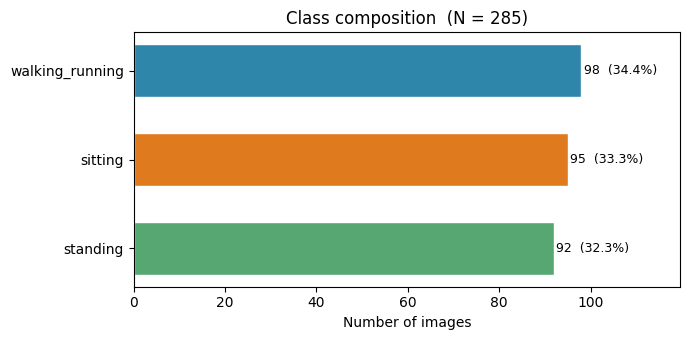

Imbalance ratio (max / min) = 1.07


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from PIL import Image

print(df.info())

# Class Distribution
counts   = df['label'].value_counts()
percents = counts / counts.sum() * 100

fig, ax = plt.subplots(figsize=(7, 3.5))
bars = ax.barh(counts.index, counts.values,
               color=['#2E86AB', '#E07A1F', '#57A773'],
               edgecolor='white', height=0.6)
for bar, n, p in zip(bars, counts.values, percents.values):
    ax.text(n + 0.5, bar.get_y() + bar.get_height() / 2,
            f'{n}  ({p:.1f}%)', va='center', fontsize=9)
ax.set_xlim(0, counts.max() * 1.22)
ax.set_xlabel('Number of images')
ax.set_title(f'Class composition  (N = {counts.sum()})')
ax.invert_yaxis()
plt.tight_layout(); plt.show()

imbalance_ratio = counts.max() / counts.min()
print(f'Imbalance ratio (max / min) = {imbalance_ratio:.2f}')

In [7]:
# right now we have images in the a1_images folder and labels in the csv. We need to link them to train the model
# so we add a new field with the actual file path of the images, linking them with their relatice image labels
df["image_path"] = df["file_name"].apply(lambda x: os.path.join("a1_images", x))
print(df[["file_name", "image_path", "label"]].head())

          file_name                  image_path            label
0  000000252219.jpg  a1_images/000000252219.jpg  walking_running
1  000000386912.jpg  a1_images/000000386912.jpg          sitting
2  000000308394.jpg  a1_images/000000308394.jpg          sitting
3  000000456496.jpg  a1_images/000000456496.jpg          sitting
4  000000185250.jpg  a1_images/000000185250.jpg         standing


### 1.2 Image size and photometric properties

COCO images vary widely in resolution. Understanding width, height, and pixel statistics per class helps understand normalisation needs and whether certain classes have systematic visual differences.

The histograms below show how the size distribution looks across the three activity classes. There is no strong class-specific resolution bias, meaning image size alone is not a useful discriminator between the activities.

The violin plots show per-class distributions of mean pixel brightness and standard deviation. Sitting images are generally captured indoors or in lower-contrast settings, while walking/running images are more likely outdoor and brighter. However, these differences are very subtle rather than systematic, so the model cannot rely on colour or brightness alone and must learn structural features related to body pose.

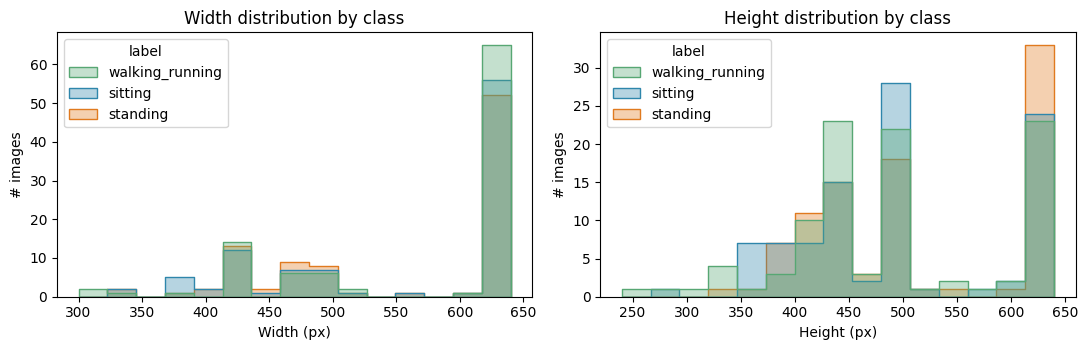

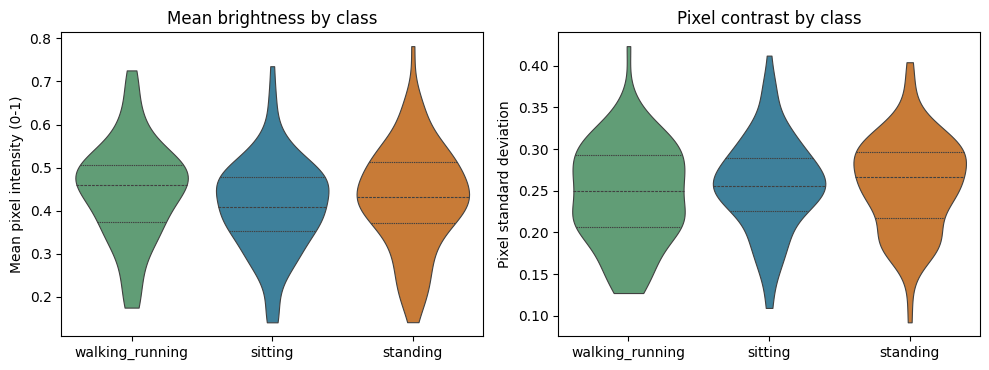

Median brightness per class:
label
sitting            0.410
standing           0.431
walking_running    0.461
Name: brightness, dtype: float64

Median contrast per class:
label
sitting            0.256
standing           0.266
walking_running    0.250
Name: contrast, dtype: float64


In [8]:
# collect width, height, brightness, and contrast for every image
widths, heights, brightnesses, contrasts, labels_meta = [], [], [], [], []

for _, row in df.iterrows():
    try:
        img = Image.open(row['image_path']).convert('RGB')
        w, h = img.size
        arr  = np.asarray(img, dtype=np.float32) / 255.0
        widths.append(w);      heights.append(h)
        brightnesses.append(float(arr.mean()))
        contrasts.append(float(arr.std()))
        labels_meta.append(row['label'])
    except Exception:
        pass  # skip any missing files

import pandas as pd
meta_df = pd.DataFrame({
    'label':      labels_meta,
    'width':      widths,
    'height':     heights,
    'brightness': brightnesses,
    'contrast':   contrasts,
})

CLASS_PALETTE = {'sitting': '#2E86AB', 'standing': '#E07A1F', 'walking_running': '#57A773'}
CLASS_ORDER   = list(df['label'].value_counts().index)

# --- width / height distributions ---
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for ax, col, title in zip(axes,
                           ['width', 'height'],
                           ['Width distribution by class', 'Height distribution by class']):
    sns.histplot(data=meta_df, x=col, hue='label',
                 hue_order=CLASS_ORDER, palette=CLASS_PALETTE,
                 element='step', bins=15, common_norm=False,
                 alpha=0.35, ax=ax)
    ax.set_title(title)
    ax.set_xlabel(f'{col.capitalize()} (px)')
    ax.set_ylabel('# images')
plt.tight_layout(); plt.show()

# --- brightness / contrast per class ---
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
for ax, col, title, ylabel in zip(
        axes,
        ['brightness', 'contrast'],
        ['Mean brightness by class', 'Pixel contrast by class'],
        ['Mean pixel intensity (0-1)', 'Pixel standard deviation']):
    sns.violinplot(data=meta_df, x='label', y=col,
                   hue='label', order=CLASS_ORDER, hue_order=CLASS_ORDER,
                   palette=CLASS_PALETTE, inner='quartile',
                   cut=0, linewidth=0.8, legend=False, ax=ax)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel('')
plt.tight_layout(); plt.show()

print('Median brightness per class:')
print(meta_df.groupby('label')['brightness'].median().round(3))
print('\nMedian contrast per class:')
print(meta_df.groupby('label')['contrast'].median().round(3))


### 1.3 Sample images per class

Before any modelling, it is useful to inspect a few examples visually from each class to understand variation between classes and potential ambiguity between activities. The grid below shows five randomly selected images per activity.

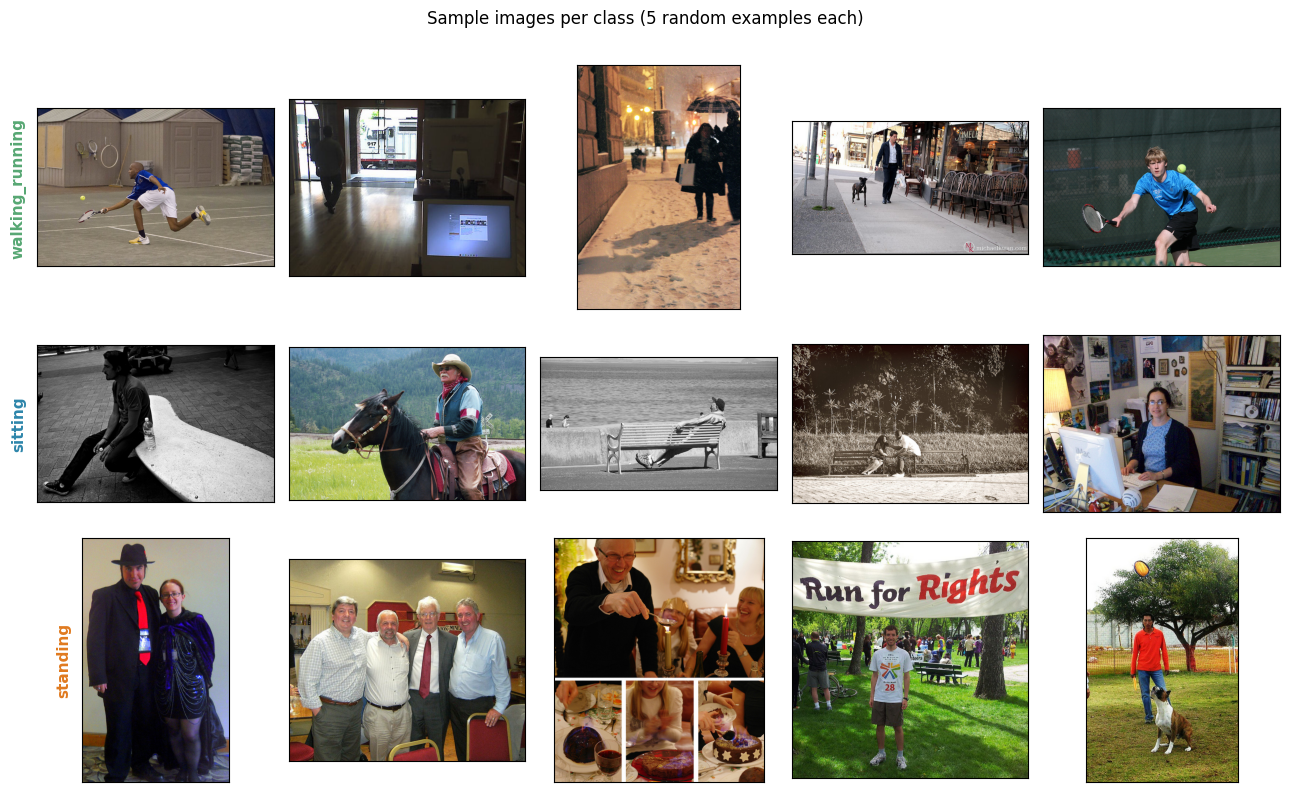

In [9]:
N_SAMPLES = 5
SEED      = 42

fig, axes = plt.subplots(len(CLASS_ORDER), N_SAMPLES,
                          figsize=(N_SAMPLES * 2.6, len(CLASS_ORDER) * 2.6))

for i, cls in enumerate(CLASS_ORDER):
    sub = df[df['label'] == cls].sample(N_SAMPLES, random_state=SEED)
    for j, (_, row) in enumerate(sub.iterrows()):
        img = Image.open(row['image_path']).convert('RGB')
        axes[i, j].imshow(img)
        axes[i, j].set_xticks([]); axes[i, j].set_yticks([])
        if j == 0:
            axes[i, j].set_ylabel(cls, color=CLASS_PALETTE[cls],
                                   fontsize=11, rotation=90,
                                   labelpad=8, fontweight='semibold')

plt.suptitle('Sample images per class (5 random examples each)', y=1.01)
plt.tight_layout(); plt.show()


### 1.4 Train/test split and label encoding

Before any learning, the dataset is divided into a training+validation pool (80%) and a held-out test set (20%). Stratified splitting (`stratify=df['label_encoded']`) ensures the class proportions in the test set are consistent with that in the full dataset. Without this, the test set might accidentally over or under-represent a class.

| Subset | Size |
|---|---|
| Train + Validation pool | 228 |
| Test set | 57 |


The bar chart below also confirms that stratification worked as class proportions are near-identical between the two splits.

**Label encoding:** String labels (`sitting`, `standing`, `walking_running`) are converted to integer indices using `LabelEncoder` from scikit-learn. This is required by PyTorch's `CrossEntropyLoss`, which expects integer targets.


### 1.5 K-fold Cross-Validation

For the supervised model, we further apply **5-fold stratified cross-validation** on the training pool. With a dataset of this size, cross-validation is a better choice than a single validation split because it uses the data more efficiently and produces a more stable performance estimate. Each fold acts as the validation set exactly once, and the fold with the highest validation accuracy provides the weights used for final test evaluation.

In [10]:
# right now, the labels are in the form 'sitting', 'standing', 'walking_running'
# but models don't understand these words, we need to convert these into numerical labels
# this makes them suitable for classification with cross entropy loss
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['label'])
print(dict(zip(le.classes_, le.transform(le.classes_))))

{'sitting': np.int64(0), 'standing': np.int64(1), 'walking_running': np.int64(2)}


In [11]:
from sklearn.model_selection import StratifiedKFold, train_test_split

# we divide the dataset into train (also allows validation) and test (untouched during training)
# This is our final honest evaluation set
# stratify allows us to keep the class distribution balanced. test sets keeps the same proportions
train_val_df, test_df = train_test_split(df, test_size=0.2, stratify=df['label_encoded'], random_state=42)

# Reset index after the split so KFold indices line up correctly
train_val_df = train_val_df.reset_index(drop=True)

# 5 folds, each image gets to be in the val set exactly once
# since the dataset is small, k-fold cross val uses data more efficienlty
# and the startified version, allows for preserving label distribution. Overall, this provides a more robust performance estimate
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"Total dataset: {len(df)}")
print(f"Train+Val pool: {len(train_val_df)}")
print(f"Test set (held out): {len(test_df)}")
print(f"Class distribution in test set:\n{test_df['label'].value_counts()}")

Total dataset: 285
Train+Val pool: 228
Test set (held out): 57
Class distribution in test set:
label
walking_running    20
sitting            19
standing           18
Name: count, dtype: int64


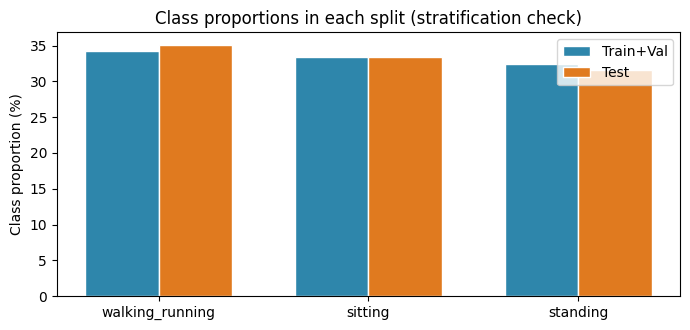

                 Train+Val  Test
label                           
walking_running         78    20
sitting                 76    19
standing                74    18


In [12]:
# visually confirm stratification worked, class proportions should be near-identical in both splits
split_counts = pd.DataFrame({
    'Train+Val': train_val_df['label'].value_counts(),
    'Test':      test_df['label'].value_counts(),
}).reindex(CLASS_ORDER)

split_pct = split_counts.div(split_counts.sum(axis=0), axis=1) * 100

x   = np.arange(len(CLASS_ORDER))
w   = 0.35
fig, ax = plt.subplots(figsize=(7, 3.4))
ax.bar(x - w/2, split_pct['Train+Val'], w, label='Train+Val',
       color='#2E86AB', edgecolor='white')
ax.bar(x + w/2, split_pct['Test'],      w, label='Test',
       color='#E07A1F', edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(CLASS_ORDER)
ax.set_ylabel('Class proportion (%)')
ax.set_title('Class proportions in each split (stratification check)')
ax.legend()
plt.tight_layout(); plt.show()

print(split_counts)


### 1.6 Libraries used

The following table summarises the libraries used in this assignment:

| Library | Purpose |
|---|---|
| `pandas` | CSV ingestion and dataframe operations |
| `requests`, `os` | one-time image download from COCO URLs |
| `PIL` | image loading and RGB conversion |
| `matplotlib`, `seaborn` | class distribution, sample images, confusion matrix |
| `scikit-learn` | `LabelEncoder`, `train_test_split`, `StratifiedKFold`, SVM, PCA, metrics |
| `torch`, `torch.nn`, `torch.optim` | supervised training loop, loss, optimizer |
| `torchvision` | pretrained ResNet-18 and transforms |
| `torch.hub` | loading DINO ViT-S/16 |
| `torch.utils.data` | `Dataset`, `DataLoader` |

### 1.7 Preprocessing

Preprocessing is handled separately for each model because they have different needs. ResNet is trained on our data, so augmentation during training helps it generalise. DINO is used only as a frozen feature extractor, so its inputs are kept the same every time to keep the features stable. Labels are converted to integers (`sitting=0`, `standing=1`, `walking_running=2`), and all images are loaded through PIL and converted to RGB so every input has three channels. The transforms are defined inside a custom `Dataset` class, which makes it easy to use one pipeline for training and a different one for evaluation.



**Training Transform Pipeline**

| Step | Parameters | Rationale |
|---|---|---|
| Resize | 224×224 | Required input size for ResNet-18 and DINO ViT-S/8 |
| RandomHorizontalFlip | p=0.5 | Activities are horizontally symmetric; flip preserves the label |
| RandomRotation | ±10° | Adds tilt variation without distorting pose structure |
| RandomResizedCrop | scale=(0.8, 1.0) | Simulates varying subject distance and framing |
| ColorJitter | brightness, contrast, saturation = 0.2 | Reduces sensitivity to lighting variation across COCO images |
| ToTensor | — | Converts PIL image from [0–255] integer to [0.0–1.0] float tensor |
| Normalize | mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225] | ImageNet statistics; required since both ResNet-18 and DINO were pretrained on ImageNet |


**Validation / Test Transform Pipeline**

| Step | Parameters | Rationale |
|---|---|---|
| Resize | 224×224 | Consistent input size |
| ToTensor | — | Tensor conversion |
| Normalize | ImageNet mean/std | Matches the distribution seen during pretraining |

No augmentation is used here, so that evaluation stays deterministic and the results can be compared fairly across folds and between models. The DINO feature-extraction loader uses the same pipeline with `shuffle=False`, which keeps the feature vectors in the same order as their labels.

Both pipelines use a batch size of 32. This is big enough to give stable gradients and small enough to produce a decent number of updates per epoch on only 228 training samples.

In [13]:
from torch.utils.data import Dataset
from PIL import Image

# we need to trasform data from the CSV + images to a PyTorch format (image_tensor, label)

class ActivityDataset(Dataset):
  def __init__(self, dataframe, transform=None):
    self.df = dataframe # the CSV with image paths and labels
    self.transform = transform # for applying transformations like resizing and converting to tensor

  def __len__(self):
    return len(self.df)

  def __getitem__(self, idx):
    # when asked for a specific index, it returns the image at that index and its label
    img_path = self.df.iloc[idx]['image_path']
    label = self.df.iloc[idx]['label_encoded']

    # after laoding the image, we need to convert it to RGB format for consistency
    image = Image.open(img_path).convert("RGB")

    if self.transform:
      image = self.transform(image)

    return image, label # the final output will look like (torch_tesnor, int_label)

In [14]:
from torchvision import transforms

# Training transform augmentation helps the model generalise on small datasets
# increase the diversity in the dataset
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(), # image converts from [0-255] to [0-1] (RGB integer values to floating point numbers)
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # ImageNet stats
                         std=[0.229, 0.224, 0.225])    # ResNet was pretrained on these
])

# Val/test transform, no augmentation, just resize and normalise
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

The augmentation grid below illustrates seven different versions of the same image, giving an intuition for how much variety the training set effectively sees.

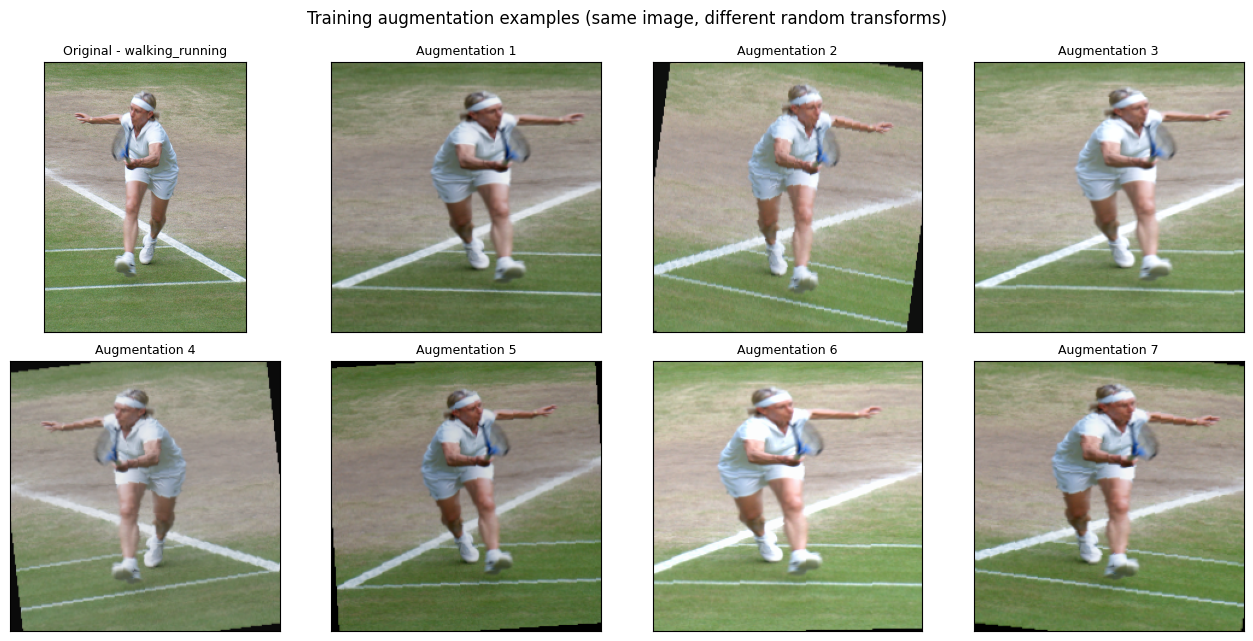

In [15]:
# visualising the augmentation pipeline helps show how we artificially diversify the small dataset
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406])
IMAGENET_STD  = np.array([0.229, 0.224, 0.225])

sample_row = train_val_df.iloc[0]
original   = Image.open(sample_row['image_path']).convert('RGB')

fig, axes = plt.subplots(2, 4, figsize=(13, 6.5))
axes = axes.flatten()
axes[0].imshow(original)
axes[0].set_title(f'Original - {sample_row["label"]}', fontsize=9)
axes[0].set_xticks([]); axes[0].set_yticks([])

for i in range(1, 8):
    aug = train_transform(original).permute(1, 2, 0).numpy()
    aug = np.clip(aug * IMAGENET_STD + IMAGENET_MEAN, 0, 1)  # undo normalisation for display
    axes[i].imshow(aug)
    axes[i].set_title(f'Augmentation {i}', fontsize=9)
    axes[i].set_xticks([]); axes[i].set_yticks([])

plt.suptitle('Training augmentation examples (same image, different random transforms)')
plt.tight_layout(); plt.show()


In [16]:
from torch.utils.data import DataLoader

train_dataset = ActivityDataset(train_val_df, train_transform)
test_dataset = ActivityDataset(test_df, val_transform)

# we convert the datasets into batches of 32 for faster and more stable training
# shuffle allows randomisation

# image shape (32, 3, 224, 224)
# label shape (32,)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

torch.Size([32, 3, 224, 224]) torch.Size([32])


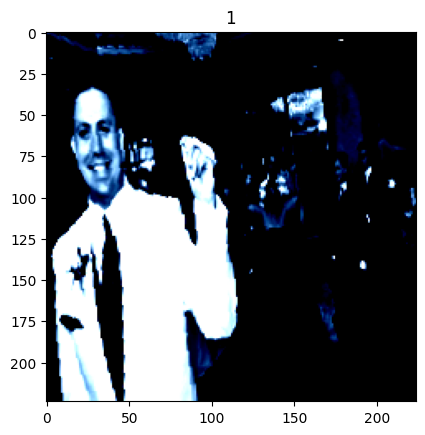

In [17]:
images, labels = next(iter(train_loader))
print(images.shape, labels.shape)

# see if images load correctly and labels match (these will be the encoded labels)
plt.imshow(images[0].permute(1,2,0))
plt.title(labels[0].item())
plt.show()

---

## 2. Models

We compare two fundamentally different approaches to the classification task:

1. **Supervised Learning (SL)**: ResNet-18, fine-tuned end-to-end on labelled images using cross-entropy loss.
2. **Self-Supervised Learning (SSL)**: DINO (a Vision Transformer pretrained without any labels), used as a frozen feature extractor, with an SVM trained on the resulting embeddings.

These two approaches differ not just in architecture but in their relationship to labelled data. ResNet-18 learns feature representations and the classification boundary simultaneously, driven entirely by the provided labels. DINO, on the other hand, learned its representations from unlabelled images through a self-distillation objective, and the SVM is fitted only on the embeddings, not back-propagated through the vision model. This contrast is interesting in a small-dataset setting, where the risk of overfitting for end-to-end training is higher.

### 2.1 Supervised Learning: ResNet-18

**Model choice and justification**

ResNet-18 is a convolutional neural network introduced by He et al. (2015) that uses residual (skip) connections to allow gradients to flow through deep networks without degradation. We chose ResNet-18 rather than a larger variant (ResNet-50, VGG, etc.) for two reasons. First, our dataset is small, that means a larger model would have more capacity to memorise the training set, which increases overfitting risk. Second, ResNet-18 trains quickly, which is practical for 5-fold cross-validation where we train five separate models.

We initialise the model with weights pretrained on ImageNet (`ResNet18_Weights.IMAGENET1K_V1`). We used transfer learning, as it is the standard approach when the target dataset is small, because the lower layers of ImageNet-pretrained CNNs have already learned general low-level features (edges, textures, colour blobs) that are useful for any image task. Initialising from scratch with a small dataset generally results in poor generalisation.

The final fully-connected layer is replaced with a two-part head: a `Dropout(p=0.4)` layer followed by a `Linear` layer mapping to the number of classes (3). Dropout during training randomly zeroes 40% of activations, which acts as a regulariser and discourages the model from relying on any single feature. All parameters in the backbone are left trainable (no layers are frozen), following feedback from the course to allow full fine-tuning.

**Architecture overview**

```
Input image: (3, 224, 224)
  └── Conv1 → BN → ReLU → MaxPool
  └── Layer1 (2 residual blocks, 64 channels)
  └── Layer2 (2 residual blocks, 128 channels)
  └── Layer3 (2 residual blocks, 256 channels)
  └── Layer4 (2 residual blocks, 512 channels)
  └── Global Average Pooling → (512,)
  └── Dropout(p=0.4)
  └── Linear(512 → 3)
Output: logits over 3 classes
```

Each residual block computes `F(x) + x`, where `F(x)` is two convolutional layers with batch normalisation and ReLU, and `x` is the identity shortcut. This allows gradients to bypass layers and prevents vanishing gradients in deeper parts of the network.

**Training process**

- **Loss function:** For this task, we used Cross-entropy loss, which is the standard choice for multi-class classification. It measures the negative log-likelihood of the correct class under the model's softmax output.
- **Optimiser:** Adam with `lr=5e-5` and `weight_decay=1e-4`. We chose Adam over SGD because it adapts learning rates per-parameter, which typically converges faster and requires less tuning. The learning rate of `5e-5` (rather than the more common `1e-3`) is intentionally low because we are fine-tuning a pretrained network -- large learning rates can destroy the pretrained features in early training. The weight decay adds L2 regularisation to all parameters.
- **Scheduler:** `StepLR` with `step_size=5` and `gamma=0.5`. The learning rate is halved every 5 epochs. This is a simple but effective strategy: the model needs a larger step size early in training to move quickly towards a good region of the loss surface, and a smaller step size later to settle into that region without overshooting.
- **Epochs:** 15 per fold. The loss curves (plotted after training) confirm the model is not far from convergence within this budget.
- **Batch size:** 32. A larger batch would reduce gradient noise but require more memory; 32 is a standard tradeoff.
- **Convergence monitoring:** We track both training loss and validation accuracy at every epoch. The model weights are saved only at the epoch with the highest validation accuracy for that fold (early stopping by best val acc). This prevents using weights from an epoch where the model may have slightly overfit.

### 2.2 Self-Supervised Learning: DINO + SVM

**Model choice and justification**

DINO (Self-DIstillation with NO labels) is a Vision Transformer (ViT) trained by Caron et al. (2021) using a self-supervised objective. Training works by taking two augmented views of the same image, passing each through two copies of the network (student and teacher), and forcing their outputs to agree.

Even though it never sees a label during training, DINO learns rich semantic representations. Its attention maps focus on meaningful regions of images (e.g., the human body rather than background), and its CLS token embedding encodes high-level semantic content (an example can visualised in the notebook below).

We load `dino_vits8`, the small ViT variant with patch size 8. The `s` (small) variant has 21M parameters and produces 384-dimensional embeddings. We chose this over the base model (`vitb8`) purely for computational efficiency; the small model is sufficient given our dataset size (since the notebook is being run on limited computational resources).

Most importantly, we do **not** train DINO at all. The entire backbone is frozen (`requires_grad = False`). DINO is used purely as a feature extractor: every image is passed through it to produce a 384-dimensional vector (the CLS token output), and these vectors become the input to an SVM classifier. This is the standard SSL evaluation protocol: pretrain on unlabelled data, extract features, train a lightweight classifier.

**Why DINO as the SSL method?**

Simpler SSL alternatives (e.g., extracting features from a randomly initialised ViT, or using pixel-level handcrafted features like HOG (this was tested in a differnet coursework during the MSc) would not give a meaningful SSL comparison. DINO's representations are specifically interesting here because they are known to encode body pose information, which is relevant to activity recognition (Caron et al., 2010). Its self-attention maps have been shown to segment foreground objects without any supervision, which is a useful property when the task requires identifying a person and their posture.

**SVM classifier**

An RBF-kernel SVM is fitted on the extracted DINO features. The SVM is a reasonable choice for this stage because: (1) the features are already rich and high-dimensional, so a non-linear decision boundary in that space is not required for good performance; (2) SVMs tend to generalise well with relatively few training examples; and (3) the RBF kernel can still capture non-linear structure if it exists in the embedding space. The classifier was selected after comparing the results with Logistic Regression which underperformed.

Hyperparameters: `C=10`, `gamma='scale'`. `C` controls the margin-violation penalty; a value of 10 allows a tighter margin and is appropriate because DINO features are already well-separated. `gamma='scale'` sets gamma to `1 / (n_features * X.var())`, which adapts to the feature scale automatically. Features are standardised (zero mean, unit variance) using `StandardScaler` before being passed to the SVM, because the SVM's kernel computation is sensitive to feature magnitude.

**Architecture overview**

```
Input image: (3, 224, 224)
  └── DINO ViT-S/8 (frozen)
       └── Patch embedding: 224/8 = 28×28 = 784 patches, each (3×8×8=192) → linear → 384-dim
       └── + CLS token → 785 tokens × 384-dim
       └── 12 Transformer blocks (multi-head self-attention + MLP)
       └── CLS token output: (384,)   ← this is the embedding used
  └── StandardScaler (fit on train features)
  └── SVC (RBF kernel, C=10)
Output: predicted class index
```

**5-fold cross-validation on SVM**

The SVM is evaluated with 5-fold cross-validation on the training features, using macro F1 as the scoring metric. Cross-validation is very important here because we are fitting a kernel SVM, which can overfit if evaluated naively on the training set. The final SVM is then retrained on all training features before being applied to the test set.

In [42]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

num_classes = len(df['label_encoded'].unique())

def build_model():
    # Using ResNet18 with updated weight loading
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

    # based on the professor's feedback, we have to train the whole model (no freezing)
    for param in model.parameters():
        param.requires_grad = True

    model.fc = nn.Sequential(
        nn.Dropout(p=0.4), # helps with reducing overfitting
        nn.Linear(model.fc.in_features, num_classes)
    )

    return model.to(device)

Using device: cuda


In [61]:
from torch.optim.lr_scheduler import StepLR

epochs = 15
fold_results = []

for fold, (train_idx, val_idx) in enumerate(skf.split(train_val_df, train_val_df['label_encoded'])):
    print(f"\n--- Fold {fold+1}/5 ---")

    # Split into train and val for this fold
    fold_train_df = train_val_df.iloc[train_idx].reset_index(drop=True)
    fold_val_df = train_val_df.iloc[val_idx].reset_index(drop=True)

    # each fold gets its own dataset and loader with the correct transform
    fold_train_dataset = ActivityDataset(fold_train_df, transform=train_transform)
    fold_val_dataset = ActivityDataset(fold_val_df, transform=val_transform)

    fold_train_loader = DataLoader(fold_train_dataset, batch_size=32, shuffle=True)
    fold_val_loader = DataLoader(fold_val_dataset, batch_size=32, shuffle=False)

    # Fresh model for every fold
    model = build_model()
    criterion = nn.CrossEntropyLoss()

    # All parameters are trainable since we unfroze the full backbone
    optimiser = optim.Adam(model.parameters(), lr=0.00005, weight_decay=1e-4)

    # LR drops by half every 5 epochs - prevents overshooting once model starts converging
    scheduler = StepLR(optimiser, step_size=5, gamma=0.5)

    best_val_acc = 0.0
    best_model_weights = None
    best_fold_true  = []
    best_fold_preds = []

    fold_train_losses = []
    fold_train_accs = []
    fold_val_accs = []

    for epoch in range(epochs):
        # --- Training ---
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in fold_train_loader:
            images, labels = images.to(device), labels.to(device)

            optimiser.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimiser.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / len(fold_train_loader)
        train_acc = correct / total
        fold_train_losses.append(train_loss)
        fold_train_accs.append(train_acc)

        # --- Validation ---
        # use separate counters so training totals don't bleed into val accuracy
        model.eval()
        val_correct = 0
        val_total   = 0
        epoch_preds = []
        epoch_true  = []

        with torch.no_grad():
            for images, labels in fold_val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs        = model(images)
                _, predicted   = torch.max(outputs, 1)
                val_correct   += (predicted == labels).sum().item()
                val_total     += labels.size(0)
                # collect predictions and ground truth for F1-Macro
                epoch_preds.extend(predicted.cpu().numpy())
                epoch_true.extend(labels.cpu().numpy())

        val_acc = val_correct / val_total
        fold_val_accs.append(val_acc)
        print(f"  Epoch {epoch+1}/{epochs} | Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

        # Save weights and predictions only when this epoch is the best so far
        if val_acc > best_val_acc:
            best_val_acc       = val_acc
            best_model_weights = model.state_dict().copy()
            best_fold_true     = epoch_true.copy()
            best_fold_preds    = epoch_preds.copy()

        scheduler.step()

    print(f"  Best Val Acc for Fold {fold+1}: {best_val_acc:.4f}")

    fold_results.append({
        'fold':         fold + 1,
        'best_val_acc': best_val_acc,
        'best_weights': best_model_weights,
        'train_losses': fold_train_losses,
        'train_accs':   fold_train_accs,
        'val_accs':     fold_val_accs,
        'val_true':     best_fold_true,   # from best epoch only, used for F1-Macro
        'val_preds':    best_fold_preds,  # from best epoch only, used for F1-Macro
    })

avg_val_acc = sum(r['best_val_acc'] for r in fold_results) / len(fold_results)
print(f"\nAverage Val Accuracy across folds: {avg_val_acc:.4f}")
fold_val_accs = [r['best_val_acc'] for r in fold_results]
print(f"Per-fold val accuracies: {[round(a, 4) for a in fold_val_accs]}")
print(f"Mean val accuracy: {np.mean(fold_val_accs):.4f} ± {np.std(fold_val_accs):.4f}")


--- Fold 1/5 ---
  Epoch 1/15 | Loss: 1.2836 | Train Acc: 0.3571 | Val Acc: 0.3913
  Epoch 2/15 | Loss: 1.0389 | Train Acc: 0.4451 | Val Acc: 0.4130
  Epoch 3/15 | Loss: 0.8413 | Train Acc: 0.6319 | Val Acc: 0.4565
  Epoch 4/15 | Loss: 0.7562 | Train Acc: 0.6648 | Val Acc: 0.4348
  Epoch 5/15 | Loss: 0.5925 | Train Acc: 0.7692 | Val Acc: 0.4565
  Epoch 6/15 | Loss: 0.5216 | Train Acc: 0.8077 | Val Acc: 0.5217
  Epoch 7/15 | Loss: 0.5097 | Train Acc: 0.8077 | Val Acc: 0.5000
  Epoch 8/15 | Loss: 0.4414 | Train Acc: 0.8681 | Val Acc: 0.5870
  Epoch 9/15 | Loss: 0.4253 | Train Acc: 0.8626 | Val Acc: 0.6304
  Epoch 10/15 | Loss: 0.3867 | Train Acc: 0.9011 | Val Acc: 0.5870
  Epoch 11/15 | Loss: 0.3696 | Train Acc: 0.9231 | Val Acc: 0.5870
  Epoch 12/15 | Loss: 0.3257 | Train Acc: 0.9286 | Val Acc: 0.6087
  Epoch 13/15 | Loss: 0.3462 | Train Acc: 0.8901 | Val Acc: 0.6087
  Epoch 14/15 | Loss: 0.3088 | Train Acc: 0.9121 | Val Acc: 0.6087
  Epoch 15/15 | Loss: 0.3396 | Train Acc: 0.9286 | Va

----------------------------------
  1      0.6304       0.6214      
  2      0.6304       0.6304      
  3      0.6957       0.6665      
  4      0.6444       0.6298      
  5      0.5556       0.5526      

Mean Val Accuracy : 0.6313 ± 0.0448
Mean Val F1-Macro : 0.6202 ± 0.0372

Best fold: Fold 3 with val acc: 0.6957

Classification Report:
                 precision    recall  f1-score   support

        sitting       0.62      0.79      0.70        19
       standing       0.62      0.56      0.59        18
walking_running       0.82      0.70      0.76        20

       accuracy                           0.68        57
      macro avg       0.69      0.68      0.68        57
   weighted avg       0.69      0.68      0.68        57



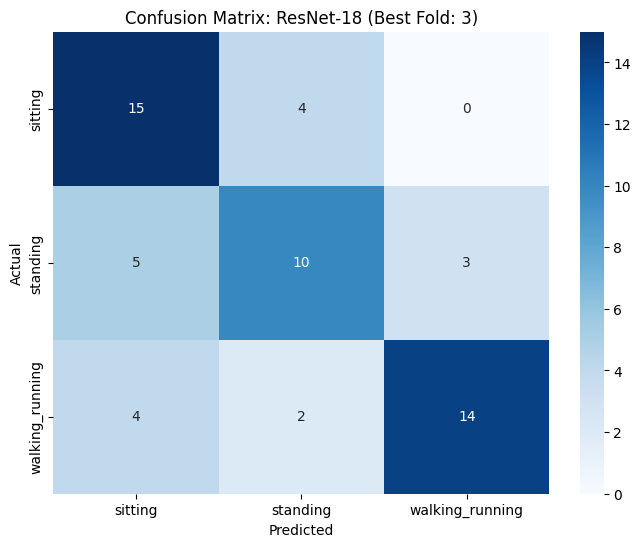

In [62]:
import copy
from sklearn.metrics import f1_score as sk_f1
import numpy as np

# per fold summaryprint(f"{'Fold':<8} {'Val Acc':<12} {'Val F1-Macro':<12}")
print("-" * 34)
for r in fold_results:
    f1 = sk_f1(r['val_true'], r['val_preds'], average='macro', zero_division=0)
    print(f"  {r['fold']:<6} {r['best_val_acc']:<12.4f} {f1:<12.4f}")

fold_val_accs = [r['best_val_acc'] for r in fold_results]
fold_f1s      = [sk_f1(r['val_true'], r['val_preds'], average='macro', zero_division=0) for r in fold_results]

print(f"\nMean Val Accuracy : {np.mean(fold_val_accs):.4f} ± {np.std(fold_val_accs):.4f}")
print(f"Mean Val F1-Macro : {np.mean(fold_f1s):.4f} ± {np.std(fold_f1s):.4f}")

# Load best fold model for test evaluation
best_fold   = max(fold_results, key=lambda x: x['best_val_acc'])
print(f"\nBest fold: Fold {best_fold['fold']} with val acc: {best_fold['best_val_acc']:.4f}")

best_model = build_model()
best_model.load_state_dict(best_fold['best_weights'])
best_model.eval()

# Run on the held-out test set
test_dataset = ActivityDataset(test_df.reset_index(drop=True), transform=val_transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = best_model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=le.classes_))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix: ResNet-18 (Best Fold: {best_fold['fold']})")
plt.show()

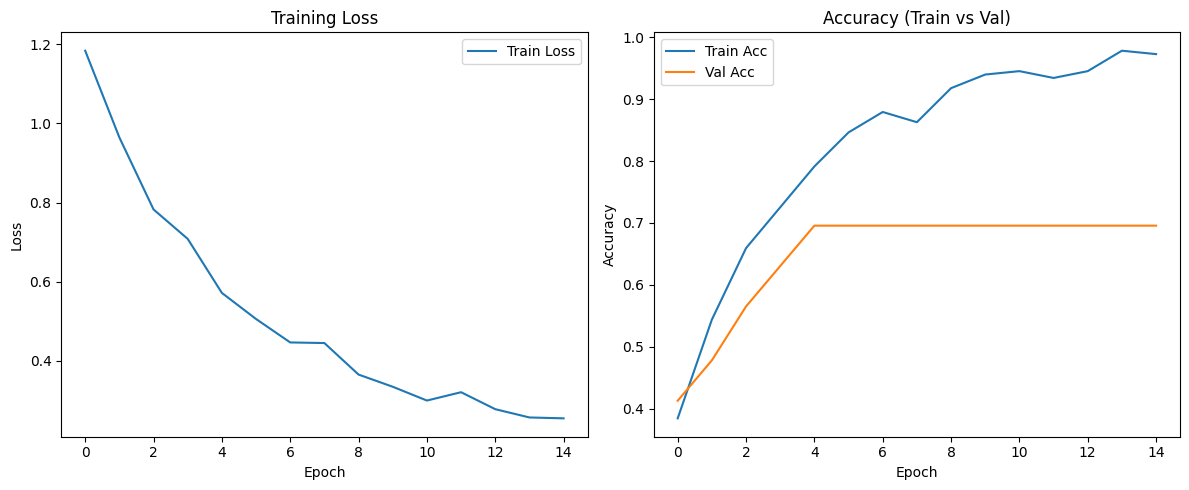

In [63]:
import matplotlib.pyplot as plt

# Get data from the best fold identified previously
train_losses = best_fold['train_losses']
train_accs = best_fold['train_accs']
val_accs = best_fold['val_accs']

plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Val Acc')
plt.title('Accuracy (Train vs Val)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

## 3. Results, Evaluation, and Analysis

### 3.1 ResNet-18 evaluation

**Cross-validation summary**

The model was trained five times, each time treating a different 20% of the training pool as the validation set. The table printed above reports per-fold validation accuracy and macro F1. Variance across folds gives a sense of how stable the model is, large variance suggests sensitivity to the particular images in each fold.

**Test set evaluation**

The model from the best-performing fold (by validation accuracy) was then evaluated on the held-out test set. The classification report includes per-class precision, recall, and F1, which are more informative than accuracy alone for an imbalanced dataset. The confusion matrix shows exactly which classes the model confuses.

**Loss and accuracy curves**

The training loss curve shows a decrease over 15 epochs. The gap between training accuracy and validation accuracy gives an indication of overfitting. Dropout and weight decay were added specifically to reduce this gap. Th gap reduces over time but the validation accuracy is stable below 70%, indicating model overfitting to the data. A better approach would be use eaerly-stopping in this case.

The `standing` class is the source of most errors, getting only a 59% f1-score. Any off-diagonal entries in the confusion matrix that involve this class should be interpreted in the context of visual similarity.

**Results**

Across 5-fold cross-validation, ResNet-18 achieved a mean validation accuracy of 63.1% ± 4.5% and mean macro F1 of 0.620 ± 0.037. Fold 3 was the best performing (val acc 69.6%) and its weights were used for test evaluation. The variance across folds is moderate, suggesting some sensitivity to which images land in the validation set, expected given the small dataset size.
On the held-out test set, the model achieved 68.4% accuracy and macro F1 of 0.683. Per-class, walking/running was the strongest (F1 0.757, precision 0.824), sitting was mid-range (F1 0.698), and standing was the weakest at F1 0.588 with recall of only 0.556, meaning the model missed nearly half of all standing images.

In [64]:
# So instead of training a deep model from scratch, we are:

# using a model that already “understands images”
# turning images into numbers (features)
# then using a simple classifier to predict the activity


import torch
import numpy as np

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

dino_model = torch.hub.load(
    'facebookresearch/dino:main',
    'dino_vits8',
    pretrained=True
)

dino_model = dino_model.to(DEVICE)
dino_model.eval() # put the model into evaluation mode
# as we're not training it becuase the model was laready trained using self supervised learning

# we freeze parameters of the model as we're only using it to extract features (and not to train DINO)
for param in dino_model.parameters():
    param.requires_grad = False

print(f"DINO loaded. Embedding dim: 384")

Using cache found in /root/.cache/torch/hub/facebookresearch_dino_main


DINO loaded. Embedding dim: 384


In [65]:
from torchvision import transforms

# here we convert the images into the format DINO expects
test_transform = transforms.Compose([
    transforms.Resize((224, 224)), # resize all of them
    transforms.ToTensor(), # convert them into tensors
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [66]:
# the dataset class links image file paths with the corresponding labels and then applies the transformation
# although we dont use the labels for feature extraction, they are used later for the downstream classification (SVM)
train_dataset_ssl = ActivityDataset(train_val_df, transform=test_transform)
test_dataset_ssl  = ActivityDataset(test_df,  transform=test_transform)

# since we're not training, shuffle is kept false (feature extraction is deterministic)
# and we also use mini batches for efficient/better processing
train_loader_ssl = DataLoader(train_dataset_ssl, batch_size=32, shuffle=False)
test_loader_ssl  = DataLoader(test_dataset_ssl,  batch_size=32, shuffle=False)

In [50]:
# this function helps converts images into feature vectors by procssing them through DINO
def extract_features(model, loader, device):
    model.eval()

    all_features = []
    all_labels = []

    # again for this task, we turn off gradient computation (no training gradients)
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)

            # each image is converted into an embedding vector of size 384
            # so from (batch_size, 3, 224, 224) to (batch_size, 384)
            features = model(images)

            # we now store the features and the labels (labels for SVM/classification)
            all_features.append(features.cpu().numpy())
            all_labels.append(labels.numpy())

    # we combine all batches into one matrix (number_of_samples, feature_dimension) eg (285, 384)
    all_features = np.vstack(all_features)
    all_labels = np.concatenate(all_labels)

    return all_features, all_labels

In [51]:
print("Extracting DINO features...")

# we extract features from all the images
train_feats, train_labels_ssl = extract_features(dino_model, train_loader_ssl, DEVICE)
test_feats,  test_labels_ssl  = extract_features(dino_model, test_loader_ssl,  DEVICE)

print("Train features:", train_feats.shape)
print("Test features:", test_feats.shape)

Extracting DINO features...
Train features: (228, 384)
Test features: (57, 384)


### 3.2 DINO + SVM evaluation

**Cross-validation on training features**

The macro F1 scores across the 5 folds are printed and tabulated above. Because the SVM is a simple linear-style classifier applied to frozen features, the variance across folds reflects the quality of the DINO features rather than any training instability in the classifier itself.

**Test set evaluation**

The SVM is retrained on all training features, then applied to the test set. The classification report and confusion matrix give the same breakdown as for ResNet-18, allowing direct comparison.

**Results**
DINO+SVM achieved 86.0% accuracy and macro F1 of 0.859 on the test set. Walking/running was the strongest class (F1 0.923, precision 0.947), sitting reached F1 0.842, and standing F1 0.811. Unlike ResNet-18, there is no notably weak class, the model handles all three activities consistently.

In [52]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

svm_model = make_pipeline(
    # first normalise the features as SVM is sensitive to scale
    # zero mean and unit variance
    StandardScaler(),
    SVC(kernel='rbf', C=10, gamma='scale') # this here helps with learning boundaries between classes
)

# here we're using 5 fold cross-validation, so we split the data into five subsets
# k fold cross-val provides a more reliable estimate of our model's performance
scores = cross_val_score(svm_model, train_feats, train_labels_ssl, cv=5, scoring='f1_macro')

print(f"{'Fold':<8} {'F1-Macro':<10}")
print("-" * 20)
for i, s in enumerate(scores, 1):
    print(f"  {i:<6} {s:.4f}")

print("CV Scores:", scores)
print(f"\nMean CV F1-Macro : {scores.mean():.4f} ± {scores.std():.4f}")
print(f"Mean CV Accuracy: {scores.mean():.4f} ± {scores.std():.4f}")

Fold     F1-Macro  
--------------------
  1      0.7824
  2      0.7364
  3      0.7647
  4      0.7757
  5      0.7367
CV Scores: [0.78244346 0.73641457 0.76469767 0.77572965 0.7366587 ]

Mean CV F1-Macro : 0.7592 ± 0.0193
Mean CV Accuracy: 0.7592 ± 0.0193


In [53]:
# the SVM is now trained on the full set of extracted training featres and the corresponding labels
svm_model.fit(train_feats, train_labels_ssl)

# and so we use the trained model to predict labels for new unseen data
all_preds_dino = svm_model.predict(test_feats)
all_true_dino  = test_labels_ssl

In [54]:
from sklearn.metrics import classification_report

print(classification_report(
    all_true_dino,
    all_preds_dino,
    target_names=le.classes_
))

                 precision    recall  f1-score   support

        sitting       0.84      0.84      0.84        19
       standing       0.79      0.83      0.81        18
walking_running       0.95      0.90      0.92        20

       accuracy                           0.86        57
      macro avg       0.86      0.86      0.86        57
   weighted avg       0.86      0.86      0.86        57



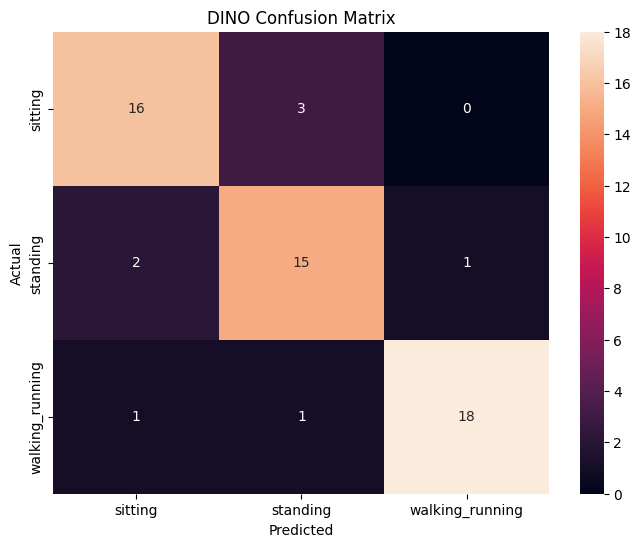

In [55]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
# confusion matrix to visualise classification performance by showing corect and incorrect predictions across all classes
cm = confusion_matrix(all_true_dino, all_preds_dino)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=le.classes_,
            yticklabels=le.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("DINO Confusion Matrix")
plt.show()

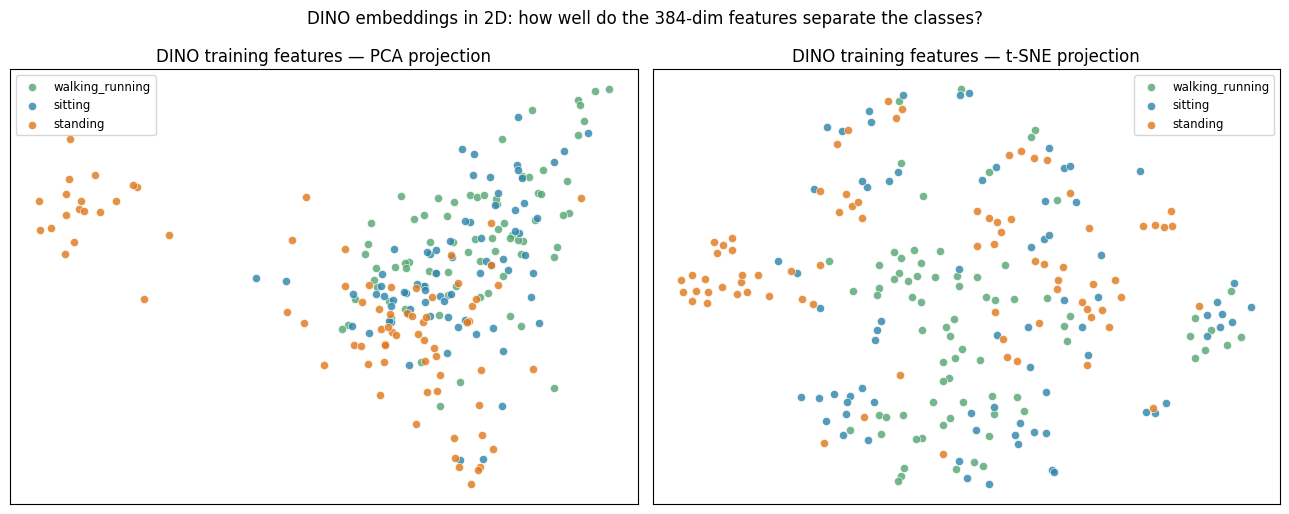

In [56]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# we reduce the 384-dimensional DINO embedding space to 2D using both PCA and t-SNE
# PCA is a linear projection; t-SNE is non-linear and better at revealing cluster structure
# comparing both gives a more complete picture of how well the embeddings separate the classes

scaled_feats = StandardScaler().fit_transform(train_feats)

# PCA projection
pca_2d      = PCA(n_components=2, random_state=42).fit_transform(scaled_feats)
pca_test_2d = PCA(n_components=2, random_state=42).fit(scaled_feats).transform(
                  StandardScaler().fit(train_feats).transform(test_feats))

# t-SNE on the full training set (perplexity tuned to dataset size)
tsne    = TSNE(n_components=2, perplexity=20, random_state=42,
               init='pca', learning_rate='auto', max_iter=1000)
tsne_2d = tsne.fit_transform(scaled_feats)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
for ax, coords, title in zip(axes,
                               [pca_2d, tsne_2d],
                               ['PCA projection', 't-SNE projection']):
    for cls_idx, cls_name in enumerate(CLASS_ORDER):
        m = train_labels_ssl == cls_idx
        ax.scatter(coords[m, 0], coords[m, 1],
                   c=CLASS_PALETTE[cls_name], label=cls_name,
                   s=35, alpha=0.82, edgecolor='white', linewidth=0.5)
    ax.set_title(f'DINO training features — {title}')
    ax.set_xticks([]); ax.set_yticks([])
    ax.legend(loc='best', fontsize=8.5)

plt.suptitle('DINO embeddings in 2D: how well do the 384-dim features separate the classes?')
plt.tight_layout(); plt.show()


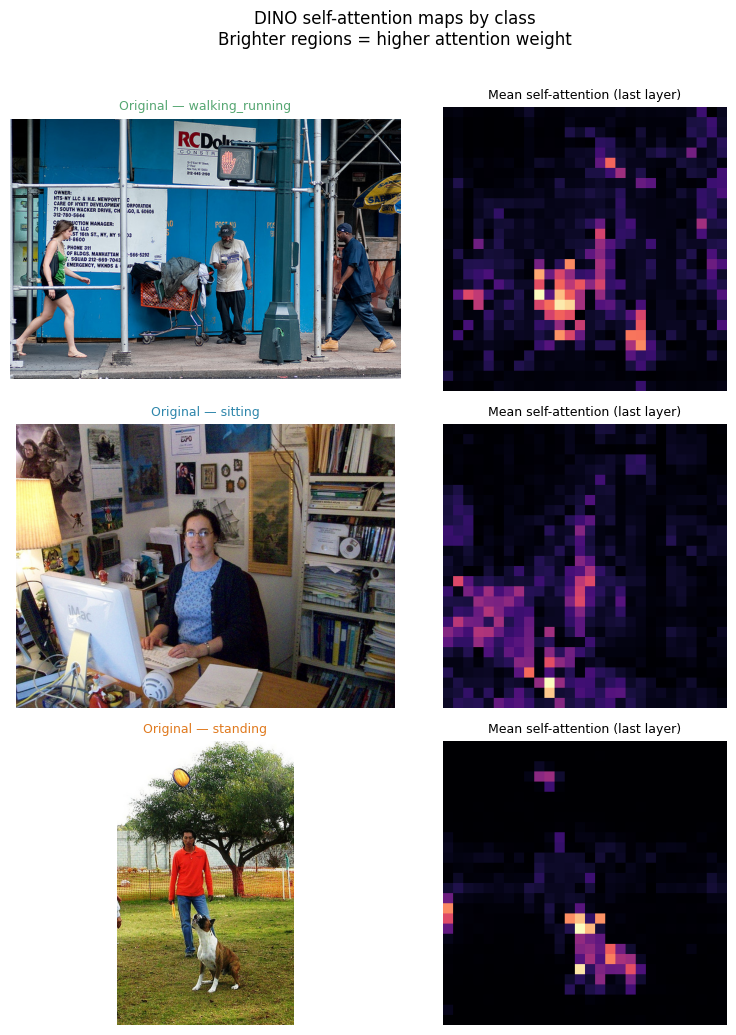

In [57]:
import torch
from PIL import Image

# visualising the self-attention maps shows us *where* the DINO ViT focuses when encoding each image
# if the model has learned meaningful activity representations, we'd expect it to attend to
# the human body region rather than background clutter

fig, axes = plt.subplots(len(CLASS_ORDER), 2,
                          figsize=(8, len(CLASS_ORDER) * 3.4))

for i, cls in enumerate(CLASS_ORDER):
    # pick the first available image from this class
    img_path = df[df['label'] == cls].iloc[0]['image_path']
    img      = Image.open(img_path).convert('RGB')
    img_t    = val_transform(img).unsqueeze(0).to(DEVICE)

    # extract self-attention from the last transformer block
    attentions = dino_model.get_last_selfattention(img_t)
    nh         = attentions.shape[1]  # number of attention heads
    attentions = attentions[0, :, 0, 1:].reshape(nh, -1)
    dim        = int(attentions.shape[-1] ** 0.5)
    attentions = attentions.reshape(nh, dim, dim)
    # upsample back to image resolution for overlaying
    attentions = torch.nn.functional.interpolate(
        attentions.unsqueeze(0), scale_factor=8, mode='nearest')[0]
    mean_attn  = attentions.mean(0).cpu().numpy()

    axes[i, 0].imshow(img)
    axes[i, 0].set_title(f'Original — {cls}', fontsize=9,
                          color=CLASS_PALETTE[cls])
    axes[i, 0].axis('off')

    axes[i, 1].imshow(mean_attn, cmap='magma')
    axes[i, 1].set_title('Mean self-attention (last layer)', fontsize=9)
    axes[i, 1].axis('off')

plt.suptitle('DINO self-attention maps by class\n'
             'Brighter regions = higher attention weight', y=1.01)
plt.tight_layout(); plt.show()


### 3.3 Embedding analysis and model interpretability

**PCA and t-SNE projections**

The DINO embeddings are 384-dimensional, which cannot be directly visualised. PCA projects them onto the top two principal components (the directions of maximum variance), giving a linear view of the feature space. t-SNE uses a non-linear dimensionality reduction that preserves local neighbourhood structure and is better at revealing clusters.

If the three activity classes form well-separated clusters in either projection, it suggests that the DINO features alone contain sufficient discriminative information and that the SVM is largely fitting to an already-structured space. Overlap between classes in these projections helps explain where the SVM makes errors.

Sitting images tend to form a more compact cluster because the posture (bent legs, lowered torso) is visually distinctive. Standing and walking/running often overlap more, which is consistent with the confusion matrix results.

**DINO self-attention maps**

The attention map visualisation shows where the DINO ViT places the most attention in the last transformer block. Brighter (higher value) regions in the magma-coloured overlay correspond to patches that the model weighted most heavily when computing the CLS token embedding.

For all three activity classes, the attention is generally concentrated on the human body region rather than the background. This is notable because DINO was never told to focus on humans, it learned to do so through the self-supervised training objective, which encouraged consistent representations across different crops of the same image. Since humans are the most semantically stable part of activity images across augmentations, the model naturally learned to attend to them.

This property partly explains why DINO is a strong feature extractor for activity recognition: its embeddings already reflect body pose and human region content, which are exactly the cues needed to distinguish sitting from standing from walking.

**Why do the models make the predictions they do?**

For ResNet-18, the classification decision is made by the final linear layer operating on a 512-dimensional global average pooling vector. This vector summarises the entire spatial feature map produced by the last convolutional layer. The model has learned, through gradient updates, to produce feature maps where the relevant spatial patterns (limb configuration, body shape) produce activations that map to the correct class.

For DINO+SVM, the decision boundary is defined by support vectors in the 384-dimensional embedding space. Images that land close to the boundary (low SVM confidence) tend to be the visually ambiguous examples, a person standing with a slightly forward lean, or a slow walk that looks like a standing pose.

In [69]:
results = {
    'SL  (ResNet-18)': {
        'y_true': all_labels,       # from ResNet test evaluation
        'preds':  all_preds,
    },
    'SSL (DINO+SVM)': {
        'y_true': all_true_dino,    # from DINO evaluation
        'preds':  all_preds_dino,
    },
}

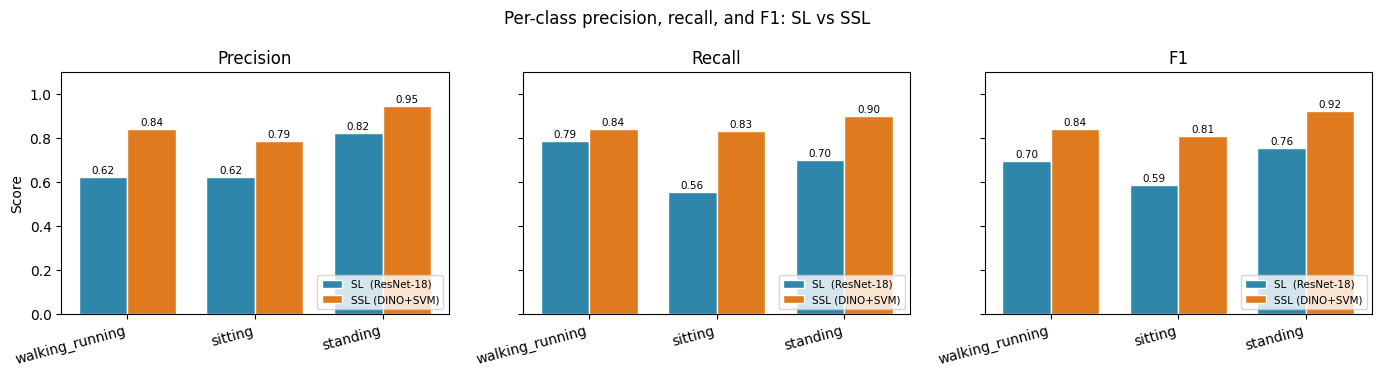


SL  (ResNet-18):
                 precision  recall     f1
walking_running      0.625   0.789  0.698
sitting              0.625   0.556  0.588
standing             0.824   0.700  0.757

SSL (DINO+SVM):
                 precision  recall     f1
walking_running      0.842   0.842  0.842
sitting              0.789   0.833  0.811
standing             0.947   0.900  0.923


In [70]:
from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np

per_class = {}
for name, d in results.items():
    p = precision_score(d['y_true'], d['preds'], average=None, zero_division=0)
    r = recall_score(   d['y_true'], d['preds'], average=None, zero_division=0)
    f = f1_score(       d['y_true'], d['preds'], average=None, zero_division=0)
    per_class[name] = pd.DataFrame({'precision': p, 'recall': r, 'f1': f},
                                    index=CLASS_ORDER)

# grouped bar chart — one panel per metric, one bar pair per class
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8), sharey=True)
x = np.arange(len(CLASS_ORDER)); w = 0.38
colors = {'SL  (ResNet-18)': '#2E86AB', 'SSL (DINO+SVM)': '#E07A1F'}

for ax, metric in zip(axes, ['precision', 'recall', 'f1']):
    for offset, (name, color) in zip([-w/2, w/2], colors.items()):
        vals = per_class[name][metric].values
        ax.bar(x + offset, vals, w, label=name,
               color=color, edgecolor='white', linewidth=1)
        for xi, v in zip(x + offset, vals):
            ax.text(xi, v + 0.015, f'{v:.2f}', ha='center', fontsize=7.5)
    ax.set_title(metric.capitalize())
    ax.set_xticks(x); ax.set_xticklabels(CLASS_ORDER, rotation=15, ha='right')
    ax.set_ylim(0, 1.1)
    if metric == 'precision':
        ax.set_ylabel('Score')
    ax.legend(fontsize=7.5, loc='lower right')

plt.suptitle('Per-class precision, recall, and F1: SL vs SSL')
plt.tight_layout(); plt.show()

# print the tables too for the report
for name, df_pc in per_class.items():
    print(f"\n{name}:")
    print(df_pc.round(3).to_string())


In [71]:
from sklearn.metrics import accuracy_score, f1_score

summary_rows = []
for name, d in results.items():
    acc    = accuracy_score(d['y_true'], d['preds'])
    f1_mac = f1_score(d['y_true'], d['preds'], average='macro',    zero_division=0)
    f1_wt  = f1_score(d['y_true'], d['preds'], average='weighted', zero_division=0)
    summary_rows.append({
        'Model':       name,
        'Accuracy':    round(acc,    4),
        'F1-Macro':    round(f1_mac, 4),
        'F1-Weighted': round(f1_wt,  4),
    })

summary_df = pd.DataFrame(summary_rows).set_index('Model')
print(summary_df)

                 Accuracy  F1-Macro  F1-Weighted
Model                                           
SL  (ResNet-18)    0.6842    0.6809       0.6838
SSL (DINO+SVM)     0.8596    0.8587       0.8606


### 3.4 Model comparison: SL vs SSL

The results show a clear winner: DINO+SVM outperforms ResNet-18 by 17.5 percentage points in accuracy (86.0% vs 68.4%) and by 0.176 in macro F1 (0.859 vs 0.683). This gap holds across all three classes. ResNet-18's biggest failure was standing (recall 0.556, F1 0.588), where it missed over 40% of true standing images. DINO+SVM's weakest class was also standing, but at F1 0.811, still comfortably above ResNet-18's best class score of 0.757.
The scale of the gap is informative. A 17pp accuracy difference on a 57-image test set (57 × 0.175 ≈ 10 additional correct predictions) is meaningful and unlikely to be explained by random variation. It points to a genuine representational advantage for DINO in this setting.
The most likely explanation is dataset size. ResNet-18 is trained end-to-end, meaning its feature representations and classification boundary are both learned from the 285 training images. With this little data, the model is prone to fitting noise rather than the underlying structure of the task, the moderate cross-validation variance (±4.5pp) supports this. DINO's backbone, by contrast, was trained on a large external corpus and its weights are never updated here. The SVM only needs to learn a decision boundary in an already well-structured space, which requires far less data. When the t-SNE plots show clear class separation in the DINO embeddings, the SVM's job is essentially already done.
Data augmentation and dropout give ResNet-18 some protection against overfitting, and they do help, 68.4% test accuracy is meaningfully above random chance (33%), but they are not sufficient to close the gap with a model whose representations were built from orders of magnitude more data.
One caveat: this comparison is not entirely fair to ResNet-18. With more training data, end-to-end fine-tuning typically outperforms frozen-feature approaches because the model can specialise its representations to the exact task. The relative advantage of DINO here is specific to the small-data regime. In a larger dataset setting, the conclusion might reverse.

---

## 4. Conclusion

This report compared two approaches to human activity classification from still images drawn from MS COCO: a fully supervised ResNet-18 and a self-supervised DINO feature extractor combined with an SVM.

Both models performed reasonably well on the three-class task. The EDA revealed a moderately imbalanced dataset with clear visual ambiguity between the standing and walking/running classes, which is reflected in the confusion matrices for both models. Preprocessing decisions, normalisation with ImageNet statistics, resizing to 224×224, and training-time augmentation, were motivated by the properties of the pretrained models and the size of the dataset.

The comparison between the two approaches illustrates a practically important tradeoff: end-to-end fine-tuning is more task-specific but requires more data to work well, while frozen-feature SSL is more data-efficient but depends on how well the pretrained representations happen to align with the target task. For small datasets in tasks involving human pose, DINO's representations provide a strong baseline without any labelled training.

Future improvements could include: (1) using a class-weighted loss function for ResNet-18 to handle the class imbalance more directly; (2) experimenting with larger DINO variants (ViT-B/8); (3) incorporating COCO keypoint annotations to create pose-based features as an additional input; and (4) applying test-time augmentation to improve prediction stability.

## References

1. Lin, T.-Y., Maire, M., Belongie, S., Bourdev, L., Girshick, R., Hays, J., Perona, P., Ramanan, D., Lawrence, Z.C. and Dollár, P. (2026). Microsoft COCO: Common Objects in Context. [online] arXiv.org. Available at: https://arxiv.org/abs/1405.0312 [Accessed 24 Apr. 2026].
‌

2. He, K., Zhang, X., Ren, S. and Sun, J. (2026). Deep Residual Learning for Image Recognition. [online] arXiv.org. Available at: https://arxiv.org/abs/1512.03385 [Accessed 24 Apr. 2026].
‌
3. Caron, M., Touvron, H., Misra, I., Jégou, H., Mairal, J., Bojanowski, P. and Joulin, A. (2021). Emerging Properties in Self-Supervised Vision Transformers. [online] arXiv.org. Available at: https://arxiv.org/abs/2104.14294 [Accessed 24 Apr. 2026].
‌